# Topic Modelling of Fantasy Premier League Tweets (2014–2022)


## Setup


In [1]:
import pandas as pd
import spacy
from collections import Counter
from tqdm import tqdm
from langdetect import detect, DetectorFactory

#Fixed seed for langdetect
DetectorFactory.seed = 0
tqdm.pandas()
pd.set_option("display.max_colwidth", 500)

## Load data 


In [2]:
df = pd.read_csv("fpl_tweets.csv")
print(f"tweets: {len(df)}")
print(f"missing values: {df['Text'].isna().sum()}")
df.head()

tweets: 114466
missing values: 0


,ID,Timestamp,User,Text,Hashtag,Retweets,Likes,Replies,Source,Location,Verified_Account,Followers,Following
0,2.855350e+17,2012-12-30 23:56:11+00:00,AmythLFC,I scored 75 points in Gameweek 20 on Fantasy Premier League http://t.co/CxBnWGk6,NaN,0,0,0,"<a href=""https://dev.twitter.com/docs/tfw"" rel=""nofollow"">Twitter for Websites</a>",NaN,False,559,812
1,2.855290e+17,2012-12-30 23:31:55+00:00,BenBoutwood,"110,525 have transferred Walcott into fantasy premier league. Shows how far one good game can get you...",NaN,0,0,0,"<a href=""http://twitter.com"" rel=""nofollow"">Twitter Web Client</a>",NaN,False,267,351
2,2.855270e+17,2012-12-30 23:24:56+00:00,ddreid88,I scored 61 points in Gameweek 20 on Fantasy Premier League http://t.co/4ys8YkcE,NaN,0,0,0,"<a href=""http://twitter.com/download/android"" rel=""nofollow"">Twitter for Android</a>",Essex,False,7,64
3,2.855270e+17,2012-12-30 23:23:26+00:00,ahmedkungora16,I scored 71 points in Gameweek 20 on Fantasy Premier League http://t.co/6XBH1fVh,NaN,0,0,0,"<a href=""https://dev.twitter.com/docs/tfw"" rel=""nofollow"">Twitter for Websites</a>",NaN,False,132,1100
4,2.855260e+17,2012-12-30 23:20:13+00:00,murray_rankin,My life's ambition is to one week be the highest scorer on Fantasy Premier League. #fpl #aiminghigh,"['fpl', 'aiminghigh']",0,0,0,"<a href=""http://twitter.com"" rel=""nofollow"">Twitter Web Client</a>","Glasgow, Scotland",False,133,453


In [3]:
#Fix timestamps to pandas
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month

#Keep only the important data (FPL season Aug–Dec)
df = df[df["Month"].isin([8, 9, 10, 11, 12])]
df = df[~df["Year"].isin([2012, 2013, 2023])]

print(f"tweets {len(df)}")

tweets 90000


## Filter English tweets


In [4]:
%%time
def filter_english(text):
    try:
        return detect(text) == "en"
    except Exception:
        return False

#Language filter befire preprocessing so we get left with only english 
df = df[df["Text"].progress_apply(filter_english)].copy()
print(f"Kept {len(df)} English tweets")

100%|████████████████████████████████████| 90000/90000 [10:14<00:00, 146.36it/s]

Kept 74197 English tweets
CPU times: user 10min 4s, sys: 7.94 s, total: 10min 12s
Wall time: 10min 15s


## Preprocess pipeline

In [5]:
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm")

#Specific stopwords for the data
FPL_STOPWORDS = {
    "fpl", "fantasy", "premier", "league", "football",
    "week", "gameweek", "gw", "matchweek", "pl", "epl",
    "fantasypremierleague", "premierleague",
}

def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = []
    for token in doc:
        lemma = token.lemma_
        if (
            token.is_alpha
            and not token.is_stop
            and not token.like_url
            and not token.like_email
            and len(token.text) >= 3
            and len(lemma) >= 3
            and lemma not in STOP_WORDS #Extra fix after analyzing withput it (drop lemmas that are stopwords after lemma)
            and lemma != "amp"
            and lemma not in FPL_STOPWORDS
        ):
            tokens.append(lemma)
    return tokens

In [6]:
%%time
#Run pipeline and get tokens 
df["Token"] = df["Text"].progress_apply(preprocess_text)

100%|████████████████████████████████████| 74197/74197 [08:34<00:00, 144.26it/s]

CPU times: user 8min 27s, sys: 5.68 s, total: 8min 33s
Wall time: 8min 34s


## Divide into periods and clean data


In [7]:
def interval_split(year):
    if 2014 <= year <= 2016:
        return "2014–2016"
    elif 2017 <= year <= 2019:
        return "2017–2019"
    elif 2020 <= year <= 2022:
        return "2020–2022"

df["Interval"] = df["Year"].apply(interval_split)

In [8]:
def clean_lda_data(df):
    print(f"rows before: {len(df)}")

    #Drop documents that are empty after preprocessing
    empty_mask = df["Token"].apply(len) == 0
    df = df.loc[~empty_mask].copy()
    print(f"removed empty documents: {empty_mask.sum()}")
    print(f"rows after empty removal: {len(df)}")

    #Remove exact duplicate in each period (only keep earliest)
    before = len(df)
    df = (
        df.sort_values("Timestamp")
          .drop_duplicates(subset=["Interval", "Text"], keep="first")
          .copy()
    )
    print(f"removed duplicates (in interval): {before - len(df)}")
    print(f"rows after duplicate removal: {len(df)}")
    return df

df = clean_lda_data(df)

rows before: 74197
removed empty documents: 1244
rows after empty removal: 72953
removed duplicates (in interval): 1200
rows after duplicate removal: 71753


In [9]:
#Save the cleaned data so we dont need to rerun the langdetect and preprocessing each time
df.to_pickle("fpl_clean.pkl")

print(f"Total doc: {len(df)}")
print(df["Interval"].value_counts())

Total doc: 71753
Interval
2017–2019    24477
2014–2016    24232
2020–2022    23044
Name: count, dtype: int64


In [10]:
#Reload
#df = pd.read_pickle("fpl_clean.pkl")

## Train LDA and evaluate coherence

Train all periods on different k-values

In [11]:
docs_2014_2016 = df.loc[df["Interval"] == "2014–2016", "Token"]
docs_2017_2019 = df.loc[df["Interval"] == "2017–2019", "Token"]
docs_2020_2022 = df.loc[df["Interval"] == "2020–2022", "Token"]

In [12]:
from gensim.corpora.dictionary import Dictionary
from gensim.models import LdaModel, CoherenceModel

def train_and_evaluate_lda(docs, num_topics_range=(5, 10, 15, 20)):
    docs = list(docs)
    dictionary = Dictionary(docs)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(doc) for doc in docs]

    results = []
    for k in num_topics_range:
        print(f"Training LDA with k={k}")
        lda = LdaModel(
            corpus=corpus, id2word=dictionary, num_topics=k,
            passes=10, iterations=100, random_state=42, alpha="auto",
        )
        coherence = CoherenceModel(
            model=lda, texts=docs, dictionary=dictionary, coherence="c_v"
        ).get_coherence()
        results.append({"k": k, "coherence": coherence, "model": lda,
                        "dictionary": dictionary, "corpus": corpus})
        print(f"  COHERENCE: {coherence:.4f}")
    return results

In [13]:
results_2014_2016 = train_and_evaluate_lda(docs_2014_2016)
print("--")
results_2017_2019 = train_and_evaluate_lda(docs_2017_2019)
print("--")
results_2020_2022 = train_and_evaluate_lda(docs_2020_2022)

Training LDA with k=5
  COHERENCE: 0.3182
Training LDA with k=10
  COHERENCE: 0.4683
Training LDA with k=15
  COHERENCE: 0.4858
Training LDA with k=20
  COHERENCE: 0.5572
--
Training LDA with k=5
  COHERENCE: 0.3515
Training LDA with k=10
  COHERENCE: 0.3777
Training LDA with k=15
  COHERENCE: 0.4078
Training LDA with k=20
  COHERENCE: 0.4344
--
Training LDA with k=5
  COHERENCE: 0.4031
Training LDA with k=10
  COHERENCE: 0.3701
Training LDA with k=15
  COHERENCE: 0.3653
Training LDA with k=20
  COHERENCE: 0.3977


In [15]:
#k=10 topics used in the results

all_results = {
    "2014–2016": results_2014_2016,
    "2017–2019": results_2017_2019,
    "2020–2022": results_2020_2022,
}
for period, results in all_results.items():
    model = next(r["model"] for r in results if r["k"] == 10)
    print("=" * 60)
    print(f"TOPICS — {period} (k=10)")
    print("=" * 60)
    for idx, topic in model.print_topics(num_words=10):
        print(f"Topic {idx}: {topic}\n")

TOPICS — 2014–2016 (k=10)
Topic 0: 0.064*"good" + 0.063*"sport" + 0.058*"fan" + 0.044*"need" + 0.043*"app" + 0.027*"hazard" + 0.026*"champion" + 0.023*"late" + 0.021*"website" + 0.017*"striker"

Topic 1: 0.094*"join" + 0.061*"private" + 0.059*"captain" + 0.038*"season" + 0.035*"play" + 0.023*"player" + 0.022*"far" + 0.021*"aguero" + 0.020*"know" + 0.018*"code"

Topic 2: 0.127*"tip" + 0.110*"preview" + 0.094*"ahead" + 0.063*"avoid" + 0.046*"manager" + 0.042*"hot" + 0.029*"bring" + 0.022*"bench" + 0.022*"daily" + 0.020*"saturday"

Topic 3: 0.083*"watch" + 0.069*"english" + 0.066*"city" + 0.063*"free" + 0.058*"manchester" + 0.036*"united" + 0.036*"stream" + 0.028*"everton" + 0.022*"illustrate" + 0.020*"west"

Topic 4: 0.169*"team" + 0.043*"game" + 0.039*"star" + 0.039*"like" + 0.031*"weekend" + 0.030*"video" + 0.027*"player" + 0.024*"squad" + 0.024*"dream" + 0.020*"look"

Topic 5: 0.238*"pick" + 0.092*"big" + 0.076*"player" + 0.070*"round" + 0.047*"english" + 0.044*"superbru" + 0.025*"zla

## Figures


{'2014–2016': [0.3182201828418549, 0.4683493568372735, 0.48578728651949393, 0.5571888444831969], '2017–2019': [0.3514750578153042, 0.3776691770238987, 0.4078426045723621, 0.4343769555998492], '2020–2022': [0.4030803807954092, 0.3700854540225751, 0.36534073574883996, 0.39770952225238215]}


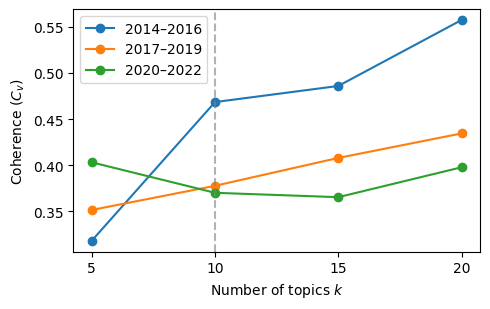

In [16]:
import matplotlib.pyplot as plt

#Figure 1
ks = [5, 10, 15, 20]
coh = {p: [next(r["coherence"] for r in res if r["k"] == k) for k in ks]
       for p, res in all_results.items()}
print(coh) 


plt.figure(figsize=(5, 3.2))
for label, vals in coh.items():
    plt.plot(ks, vals, marker="o", label=label)
plt.axvline(10, ls="--", c="gray", alpha=0.6)
plt.xticks(ks)
plt.xlabel("Number of topics $k$")
plt.ylabel("Coherence ($C_v$)")
plt.legend()
plt.tight_layout()
plt.savefig("coherence_vs_k.pdf")
plt.show()

{'2014–2016': [518, 413, 76, 2, 92, 0], '2017–2019': [467, 15, 3, 531, 551, 0], '2020–2022': [14, 8, 0, 604, 256, 330]}


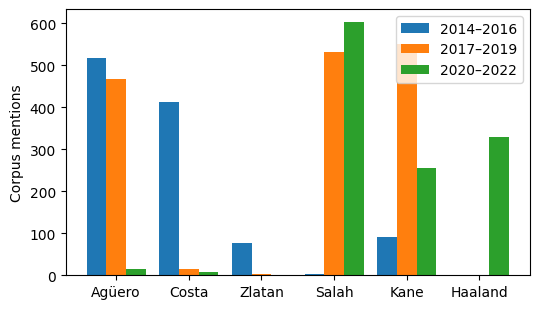

In [17]:
import numpy as np

#Figure 2
player_tokens = ["aguero", "costa", "zlatan", "salah", "kane", "haaland"]
player_labels = ["Agüero", "Costa", "Zlatan", "Salah", "Kane", "Haaland"]
periods = ["2014–2016", "2017–2019", "2020–2022"]

counts = {}
for iv in periods:
    c = Counter(t for toks in df.loc[df["Interval"] == iv, "Token"] for t in toks)
    counts[iv] = [c[p] for p in player_tokens]
print(counts)

x = np.arange(len(player_labels))
w = 0.27
plt.figure(figsize=(5.5, 3.2))
for i, iv in enumerate(periods):
    plt.bar(x + (i - 1) * w, counts[iv], w, label=iv)
plt.xticks(x, player_labels)
plt.ylabel("Corpus mentions")
plt.legend()
plt.tight_layout()
plt.savefig("player_mentions.pdf")
plt.show()

In [19]:
#FPLCommunity hashtag freq
for iv in periods:
    c = Counter(t for toks in df.loc[df["Interval"] == iv, "Token"] for t in toks)
    print(iv, "fplcommunity", c["fplcommunity"])

2014–2016 fplcommunity 2
2017–2019 fplcommunity 230
2020–2022 fplcommunity 1061
